**Capítulo 2 (adaptado) — Projeto de Machine Learning Ponta a Ponta**

*Baseado na estrutura do notebook `02_end_to_end_machine_learning_project.ipynb` (Aurélien Géron).*

*O dataset original (California Housing / Regressão) foi substituído pelo **Wine Recognition Dataset** (UCI / Kaggle) para uma tarefa de **Classificação Multiclasse** com os algoritmos KNN, Random Forest e Naive Bayes.*

# Setup

In [55]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import pandas as pd
import os
import time
import warnings
warnings.filterwarnings('ignore')

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "wine_classification"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

np.random.seed(42)
print('✅ Setup concluído!')
print(f'   Python       : {sys.version.split()[0]}')
print(f'   Scikit-Learn : {sklearn.__version__}')

✅ Setup concluído!
   Python       : 3.12.13
   Scikit-Learn : 1.6.1


# Get the Data

## Download the Data

In [56]:
# ─────────────────────────────────────────────────────────────────
# OPÇÃO 1 — Via Kaggle API:
#   !pip install kaggle
#   !kaggle datasets download -d harrywang/wine-dataset-for-clustering
#   !unzip wine-dataset-for-clustering.zip
#   wine_data = pd.read_csv('wine-clustering.csv')
#
# OPÇÃO 2 — Direto do sklearn (usada aqui — zero configuração):
# ─────────────────────────────────────────────────────────────────

from sklearn.datasets import load_wine

def fetch_wine_data():
    """Carrega o Wine Recognition Dataset do sklearn.
    Equivalente ao fetch_housing_data() do Cap. 2 original.
    Fonte: UCI ML Repository / Kaggle: harrywang/wine-dataset-for-clustering
    """
    raw = load_wine()
    df  = pd.DataFrame(raw.data, columns=raw.feature_names)
    df['target'] = raw.target  # 0=Cultivar A | 1=Cultivar B | 2=Cultivar C
    return df, raw.target_names

wine, TARGET_NAMES = fetch_wine_data()
print('✅ Dataset carregado!')
print(f'   Fonte   : UCI Machine Learning Repository / Kaggle')
print(f'   Shape   : {wine.shape}')
print(f'   Classes : {list(TARGET_NAMES)}')

✅ Dataset carregado!
   Fonte   : UCI Machine Learning Repository / Kaggle
   Shape   : (178, 14)
   Classes : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


## Take a Quick Look at the Data Structure

In [57]:
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [58]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [59]:
wine['target'].value_counts()

,count
target,
1,71
0,59
2,48


In [60]:
wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Saving figure attribute_histogram_plots


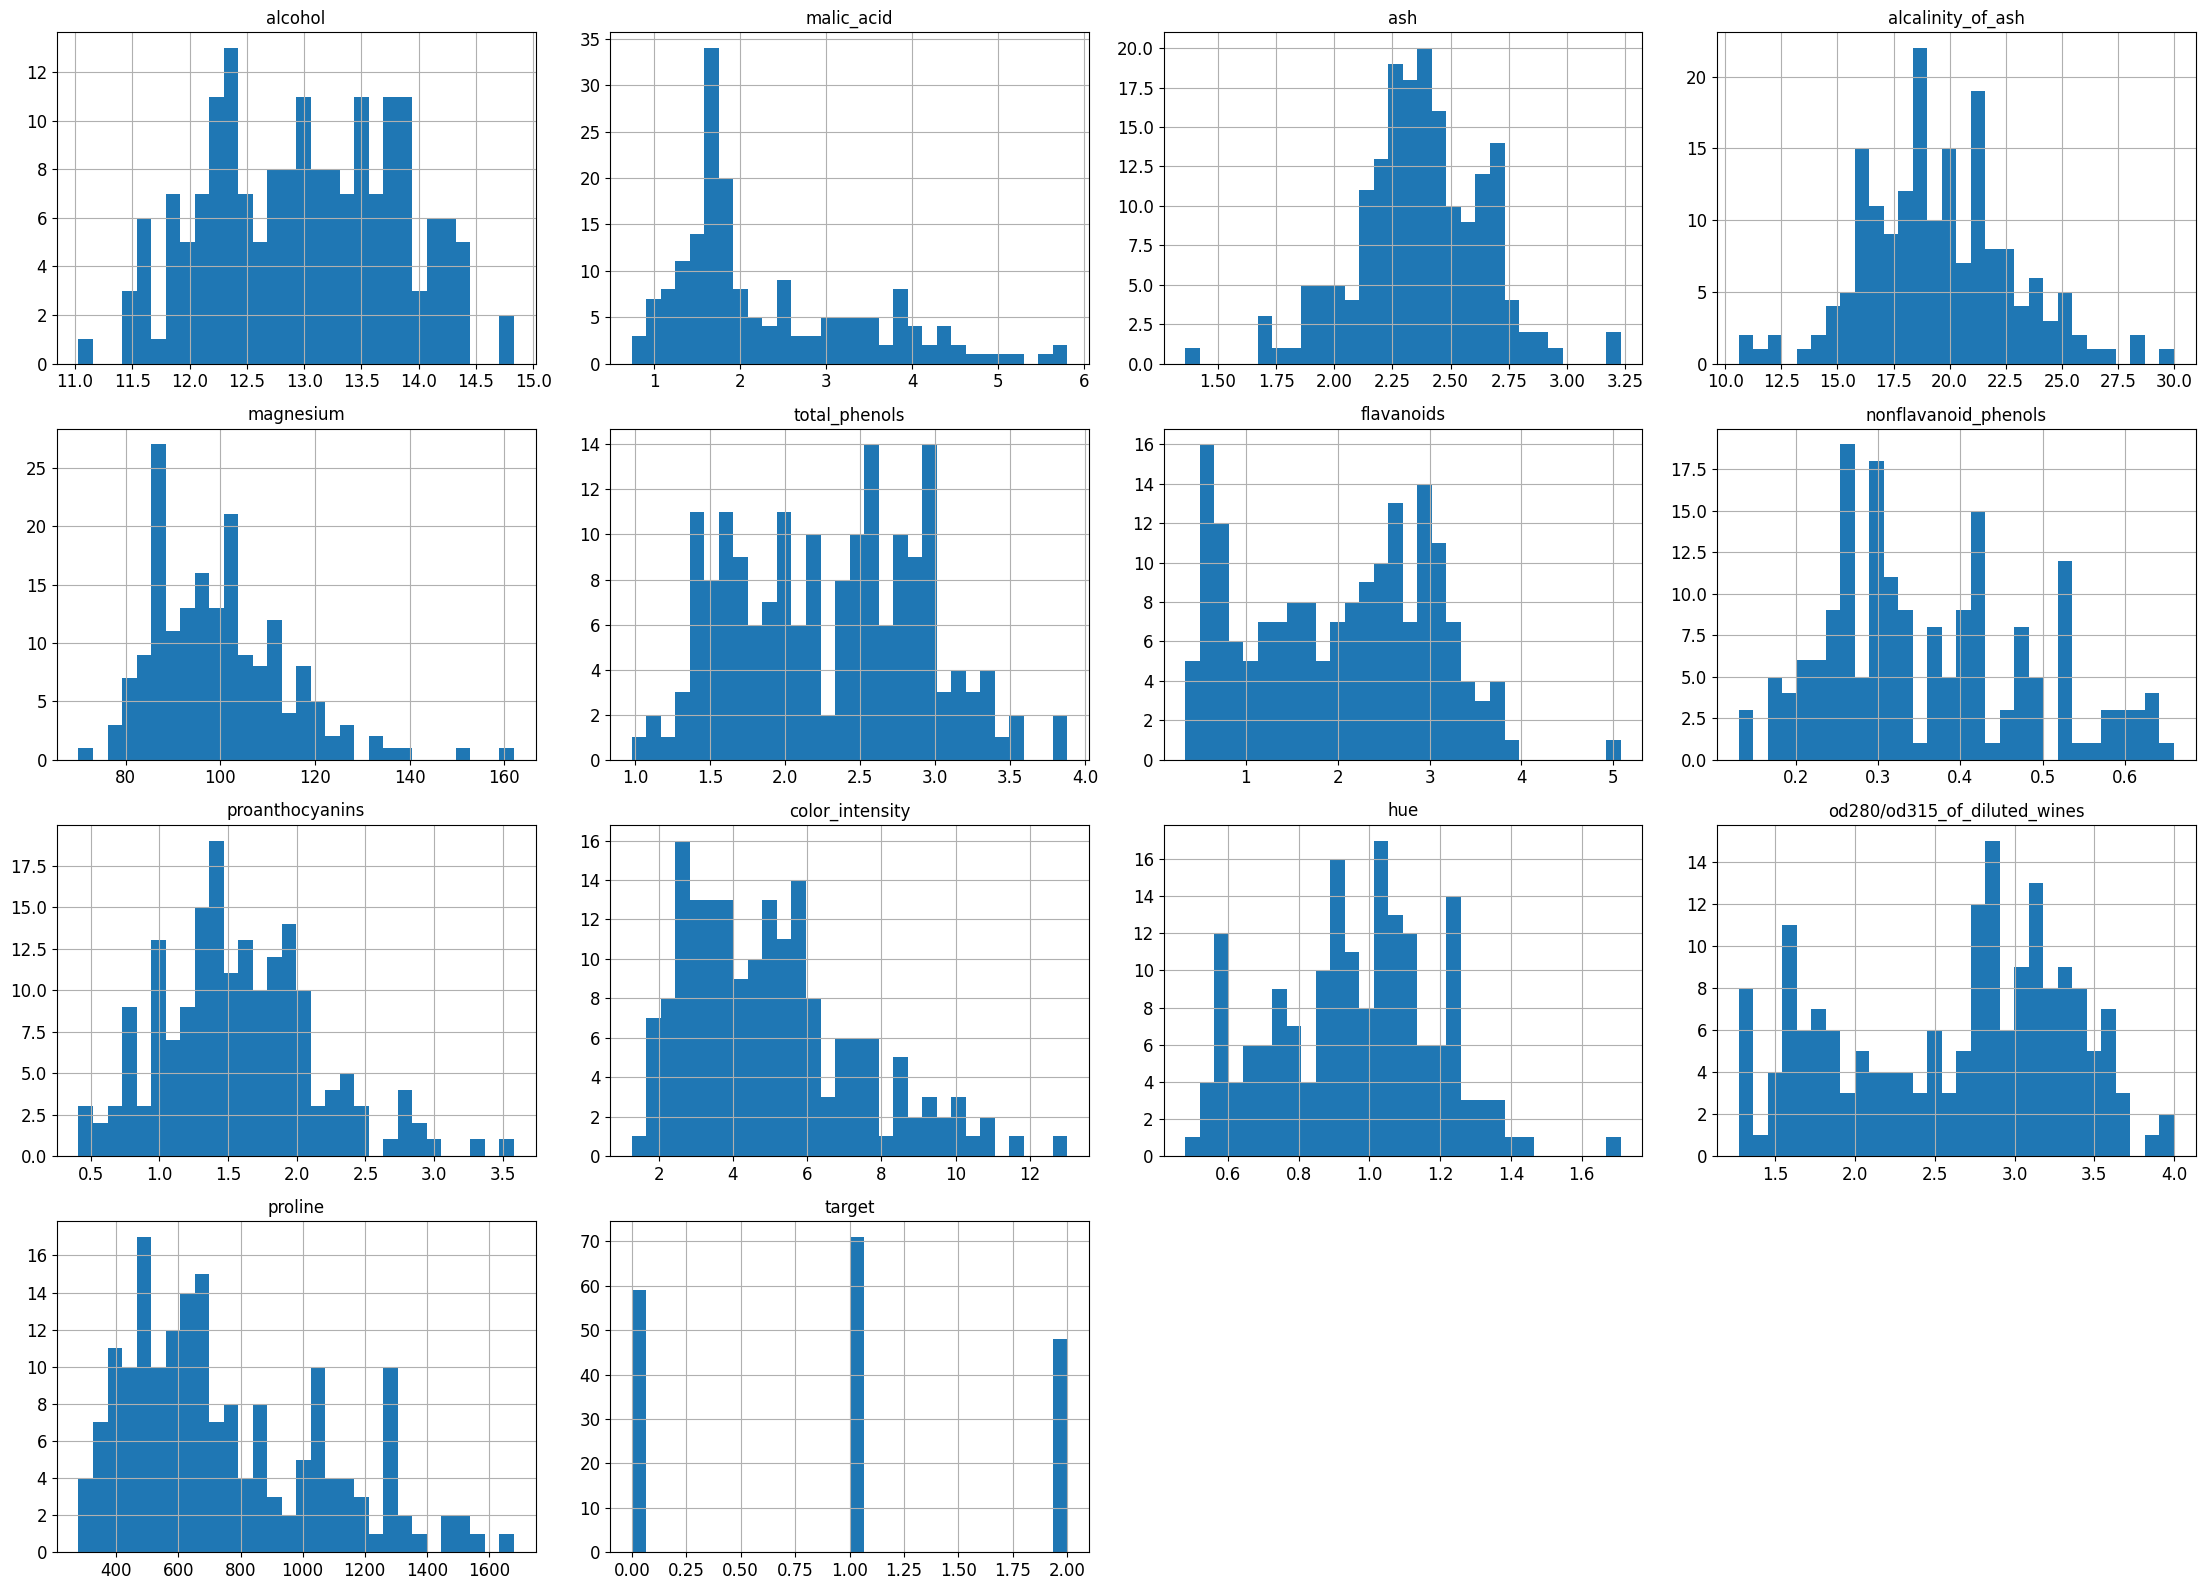

In [61]:
# Histogramas de todas as features — igual ao do Cap. 2
wine.hist(bins=30, figsize=(22, 16))
save_fig("attribute_histogram_plots")
plt.show()

## Create a Test Set

In [62]:
# Mesmo método do Cap. 2: StratifiedShuffleSplit
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(wine, wine["target"]):
    strat_train_set = wine.loc[train_index].reset_index(drop=True)
    strat_test_set  = wine.loc[test_index].reset_index(drop=True)

print(f'Treino : {len(strat_train_set):,} amostras')
print(f'Teste  : {len(strat_test_set):,} amostras')
print()
print('Proporção das classes:')
print('  Dataset completo:')
print(wine['target'].value_counts() / len(wine))
print('  Treino:')
print(strat_train_set['target'].value_counts() / len(strat_train_set))

Treino : 142 amostras
Teste  : 36 amostras

Proporção das classes:
  Dataset completo:
target
1    0.398876
0    0.331461
2    0.269663
Name: count, dtype: float64
  Treino:
target
1    0.401408
0    0.330986
2    0.267606
Name: count, dtype: float64


In [63]:
# Verificar proporção preservada — igual ao do Cap. 2
def target_proportions(data):
    return data['target'].value_counts() / len(data)

compare_props = pd.DataFrame({
    'Geral':       target_proportions(wine),
    'Treino':      target_proportions(strat_train_set),
    'Teste':       target_proportions(strat_test_set),
})
compare_props['Erro % (Treino)'] = (
    100 * compare_props['Treino'] / compare_props['Geral'] - 100
).round(2)
compare_props

,Geral,Treino,Teste,Erro % (Treino)
target,,,,
1,0.398876,0.401408,0.388889,0.63
0,0.331461,0.330986,0.333333,-0.14
2,0.269663,0.267606,0.277778,-0.76


# Discover and Visualize the Data to Gain Insights

In [64]:
# Trabalhamos sempre no conjunto de treino
wine_train = strat_train_set.copy()

## Visualizing the Data

Saving figure target_distribution


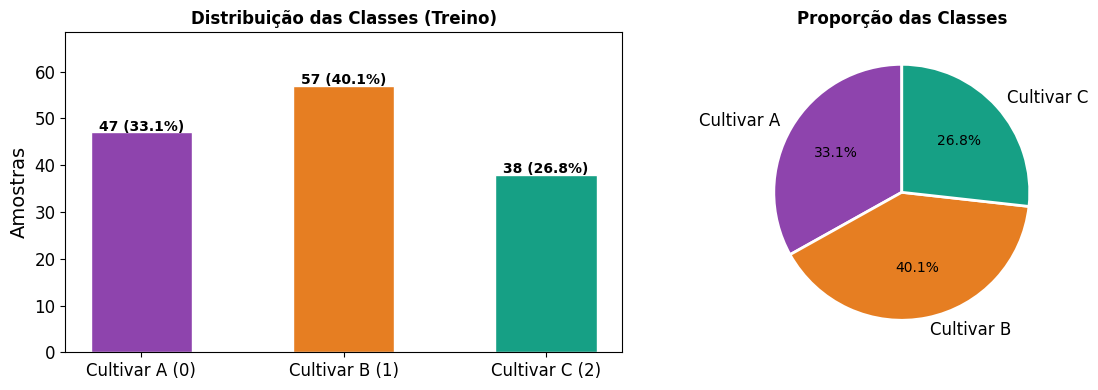

In [65]:
# Distribuição do target
CORES_CLS = ['#8e44ad','#e67e22','#16a085']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

counts = wine_train['target'].value_counts().sort_index()
rotulos = ['Cultivar A (0)','Cultivar B (1)','Cultivar C (2)']

bars = ax1.bar(rotulos, counts.values, color=CORES_CLS, edgecolor='white', width=0.5)
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
             f'{int(b.get_height())} ({b.get_height()/len(wine_train)*100:.1f}%)',
             ha='center', fontweight='bold')
ax1.set_title('Distribuição das Classes (Treino)', fontweight='bold')
ax1.set_ylabel('Amostras')
ax1.set_ylim(0, max(counts.values)*1.2)

ax2.pie(counts.values, labels=['Cultivar A','Cultivar B','Cultivar C'],
        colors=CORES_CLS, autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Proporção das Classes', fontweight='bold')

save_fig("target_distribution")
plt.show()

Saving figure best_features_boxplots


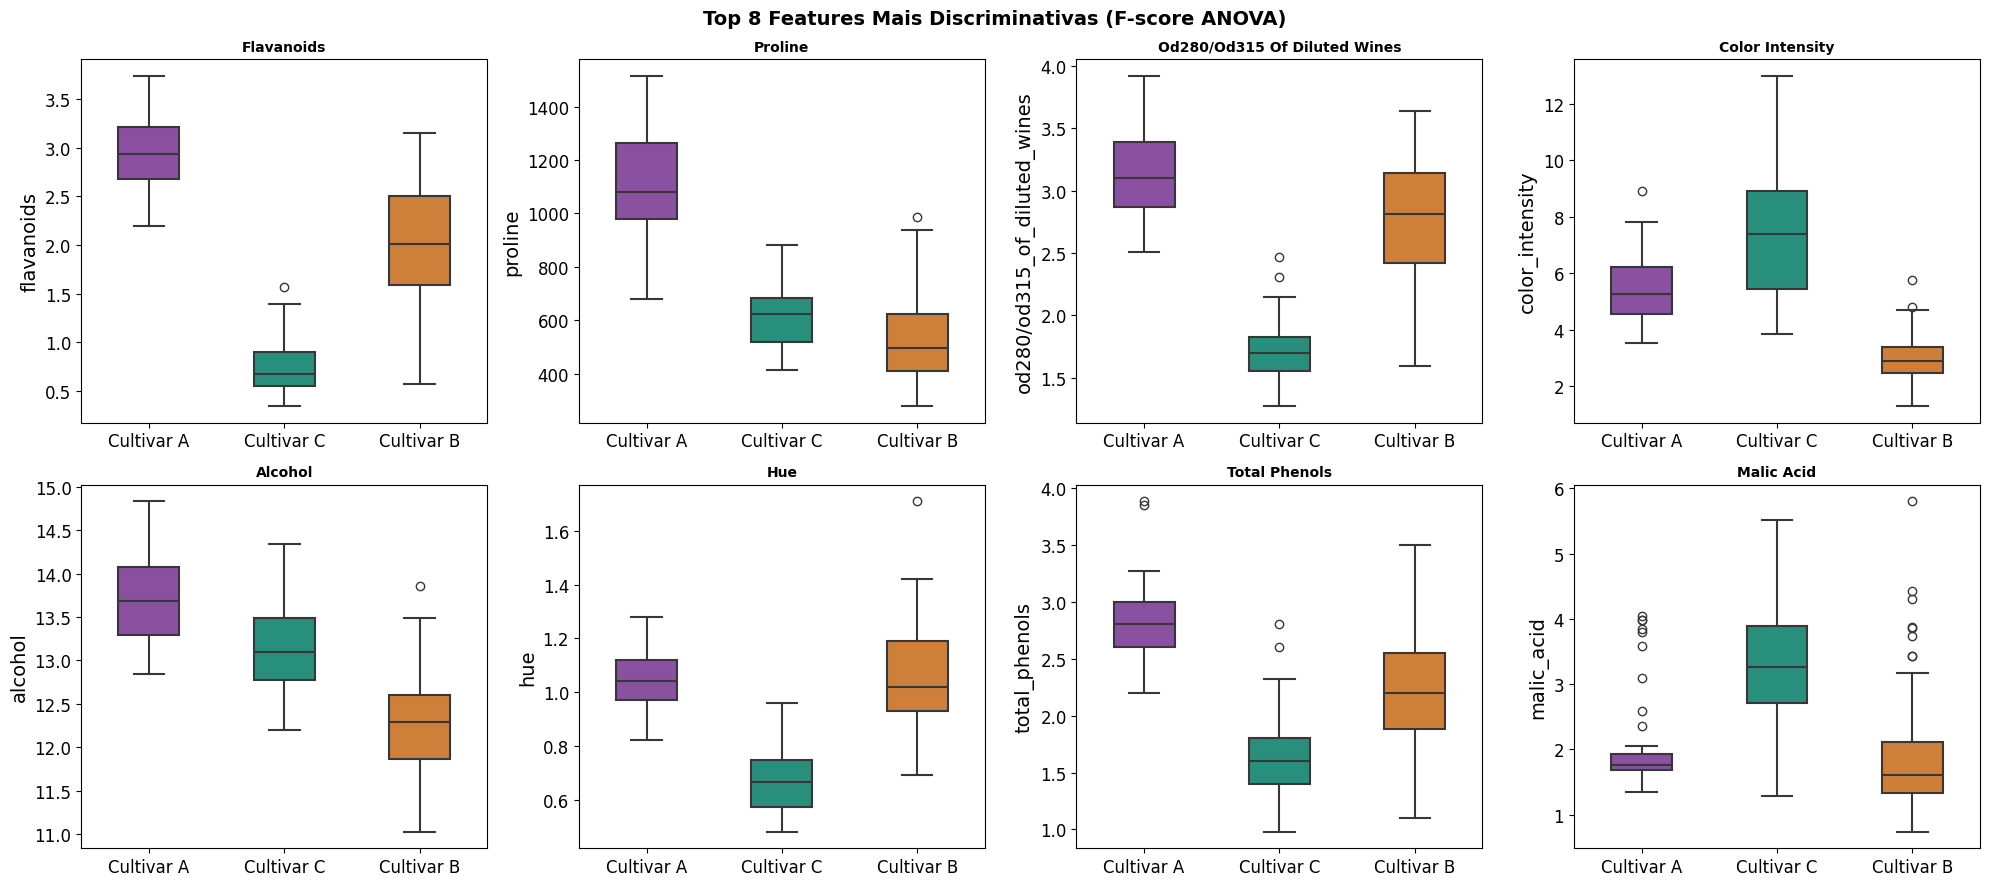

In [66]:
# Boxplots das features mais discriminativas — analog ao scatter geográfico do Cap. 2
from sklearn.feature_selection import f_classif

X_vis = wine_train.drop('target', axis=1)
y_vis = wine_train['target']
f_scores, _ = f_classif(X_vis, y_vis)
top8_idx  = np.argsort(f_scores)[::-1][:8]
top8_feat = [X_vis.columns[i] for i in top8_idx]

wine_plot = wine_train.copy()
wine_plot['Cultivar'] = wine_plot['target'].map(
    {0:'Cultivar A', 1:'Cultivar B', 2:'Cultivar C'})

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
pal = {'Cultivar A': CORES_CLS[0], 'Cultivar B': CORES_CLS[1], 'Cultivar C': CORES_CLS[2]}

for i, feat in enumerate(top8_feat):
    sns.boxplot(data=wine_plot, x='Cultivar', y=feat,
                palette=pal, ax=axes[i], width=0.45, linewidth=1.5)
    axes[i].set_title(feat.replace('_',' ').title(), fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Top 8 Features Mais Discriminativas (F-score ANOVA)',
             fontsize=14, fontweight='bold')
save_fig("best_features_boxplots")
plt.show()

## Looking for Correlations

In [67]:
corr_matrix = wine_train.corr(numeric_only=True)
corr_matrix['target'].sort_values(ascending=False)

,target
target,1.000000
alcalinity_of_ash,0.507562
nonflavanoid_phenols,0.476767
malic_acid,0.418279
color_intensity,0.268592
ash,-0.044951
magnesium,-0.207569
alcohol,-0.331843
proanthocyanins,-0.481488
hue,-0.605732


Saving figure correlation_matrix


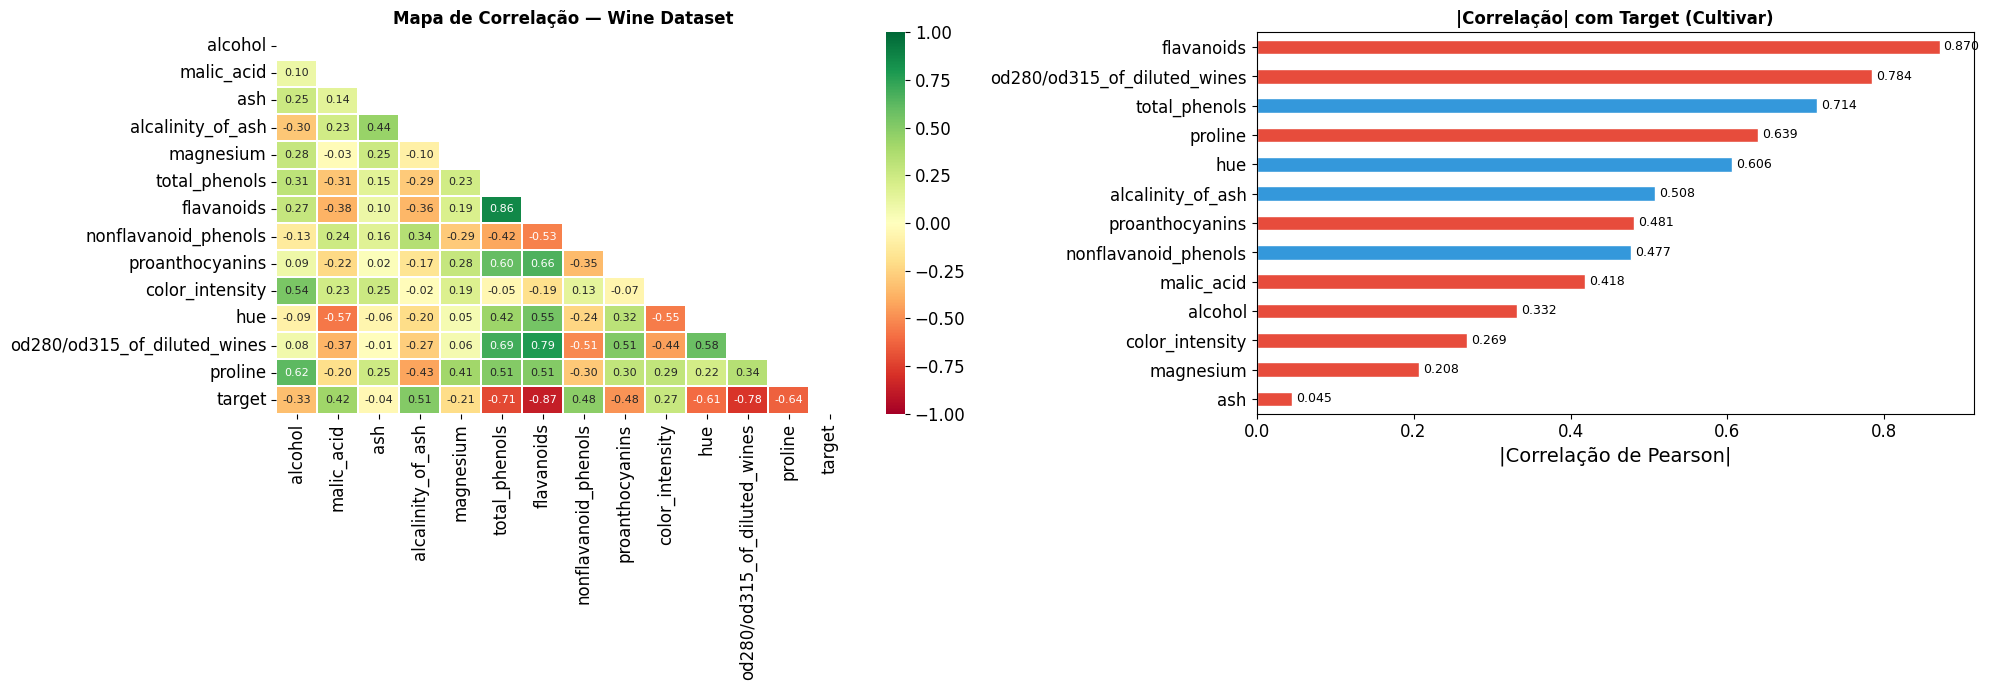

In [68]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.3, ax=ax1,
            vmin=-1, vmax=1, annot_kws={'size': 8})
ax1.set_title('Mapa de Correlação — Wine Dataset', fontweight='bold')

tc = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
cores_bar = ['#e74c3c' if corr_matrix['target'][f]<0 else '#3498db' for f in tc.index]
tc.plot(kind='barh', ax=ax2, color=cores_bar[::-1], edgecolor='white')
ax2.invert_yaxis()
ax2.set_title('|Correlação| com Target (Cultivar)', fontweight='bold')
ax2.set_xlabel('|Correlação de Pearson|')
for i, v in enumerate(tc.values):
    ax2.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=9)

save_fig("correlation_matrix")
plt.show()

Saving figure scatter_matrix


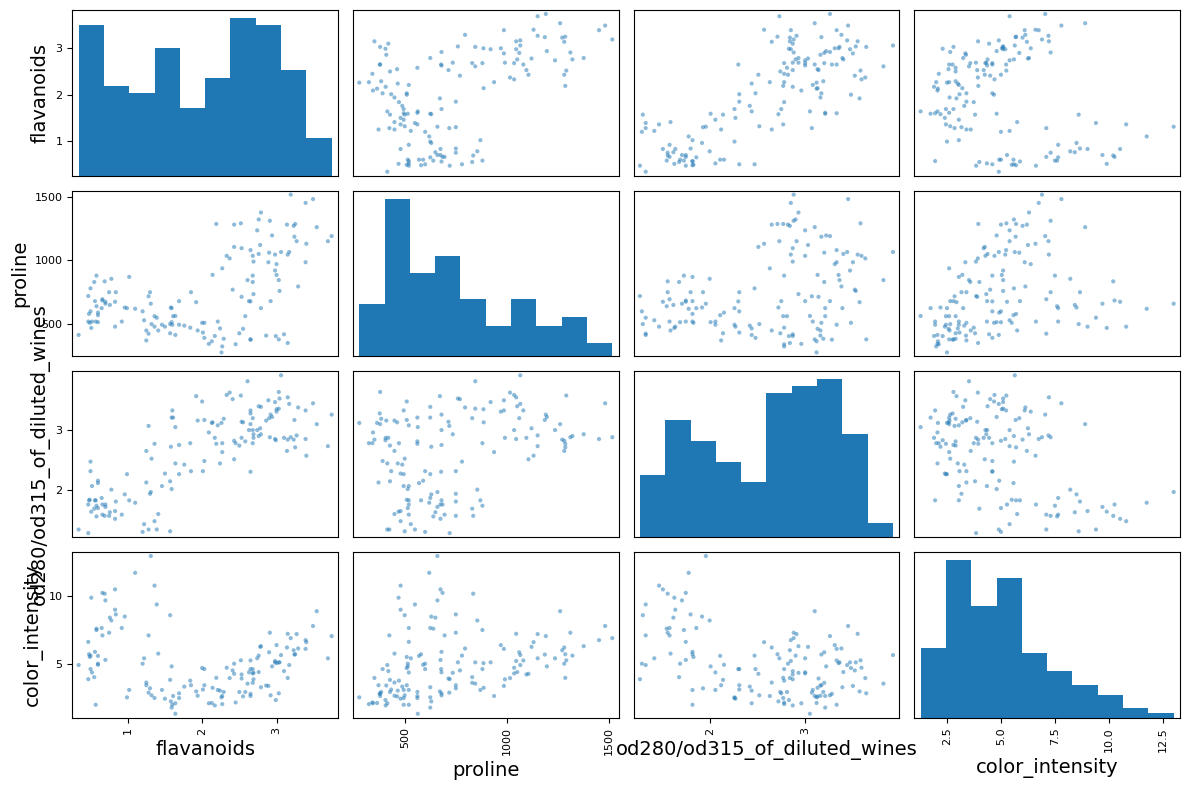

In [69]:
# Scatter matrix — equivalente ao do Cap. 2
from pandas.plotting import scatter_matrix

top4 = top8_feat[:4]
scatter_matrix(wine_train[top4], figsize=(12, 8))
save_fig("scatter_matrix")
plt.show()

## Experimenting with Attribute Combinations

In [70]:
# Criar features combinadas — mesmo conceito do Cap. 2
wine_train['alcohol_acid_ratio']  = wine_train['alcohol'] / (wine_train['malic_acid'] + 1e-6)
wine_train['polyphenol_index']    = wine_train['total_phenols'] + wine_train['flavanoids'] + wine_train['proanthocyanins']
wine_train['flavanoid_ratio']     = wine_train['flavanoids'] / (wine_train['total_phenols'] + 1e-6)
wine_train['color_score']         = wine_train['color_intensity'] * wine_train['hue']

# Verificar correlação das novas features
corr_matrix2 = wine_train.corr(numeric_only=True)
novas = ['alcohol_acid_ratio','polyphenol_index','flavanoid_ratio','color_score']
print('Correlação das novas features com target:')
print(corr_matrix2['target'][novas].sort_values(ascending=False).round(3))

Correlação das novas features com target:
color_score          -0.254
alcohol_acid_ratio   -0.369
flavanoid_ratio      -0.778
polyphenol_index     -0.795
Name: target, dtype: float64


# Prepare the Data for Machine Learning Algorithms

In [71]:
# Separar features e target — mesmo do Cap. 2
wine_feat = strat_train_set.drop('target', axis=1)
wine_labels = strat_train_set['target'].copy()

print(f'X_train shape: {wine_feat.shape}')
print(f'y_train shape: {wine_labels.shape}')

X_train shape: (142, 13)
y_train shape: (142,)


## Data Cleaning

In [72]:
# Verificar valores ausentes — igual ao do Cap. 2
print('Valores ausentes por coluna:')
missing = wine_feat.isnull().sum()
if missing.sum() == 0:
    print('  ✅ Nenhum valor ausente! (Wine dataset já vem limpo)')
else:
    print(missing[missing > 0])

# Mesmo do Cap. 2: SimpleImputer (pronto para escalar)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
wine_num = wine_feat.select_dtypes(include=[np.number])
imputer.fit(wine_num)
print()
print('Medianas calculadas pelo imputer:')
print(pd.Series(imputer.statistics_, index=wine_num.columns).round(3))

Valores ausentes por coluna:
  ✅ Nenhum valor ausente! (Wine dataset já vem limpo)

Medianas calculadas pelo imputer:
alcohol                          13.010
malic_acid                        1.810
ash                               2.360
alcalinity_of_ash                19.500
magnesium                        97.000
total_phenols                     2.335
flavanoids                        2.135
nonflavanoid_phenols              0.340
proanthocyanins                   1.560
color_intensity                   4.640
hue                               0.960
od280/od315_of_diluted_wines      2.780
proline                         673.500
dtype: float64


## Custom Transformers

In [73]:
# Transformer customizado — mesmo padrão do CombinedAttributesAdder do Cap. 2
from sklearn.base import BaseEstimator, TransformerMixin

class WineAttributesAdder(BaseEstimator, TransformerMixin):
    """
    Equivalente ao CombinedAttributesAdder do Cap. 2.
    Cria features derivadas com significado químico/enológico.
    """
    def __init__(self, add_color_score=True):
        self.add_color_score = add_color_score

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Razão álcool / acidez — equilíbrio sensorial
        X['alcohol_acid_ratio'] = X['alcohol'] / (X['malic_acid'] + 1e-6)
        # Índice de polifenóis — qualidade antioxidante
        X['polyphenol_index']   = X['total_phenols'] + X['flavanoids'] + X['proanthocyanins']
        # Razão flavonoides / fenóis totais — indicador de maturidade
        X['flavanoid_ratio']    = X['flavanoids'] / (X['total_phenols'] + 1e-6)
        if self.add_color_score:
            # Score de cor — intensidade × tonalidade
            X['color_score']    = X['color_intensity'] * X['hue']
        return X

# Testar
adder = WineAttributesAdder()
X_extra = adder.fit_transform(wine_feat)
novas = set(X_extra.columns) - set(wine_feat.columns)
print(f'Features originais : {wine_feat.shape[1]}')
print(f'Após transformer   : {X_extra.shape[1]}')
print(f'Novas features     : {sorted(novas)}')

Features originais : 13
Após transformer   : 17
Novas features     : ['alcohol_acid_ratio', 'color_score', 'flavanoid_ratio', 'polyphenol_index']


## Transformation Pipelines

In [74]:
# Pipeline numérico — mesmo do Cap. 2
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('attribs_adder', WineAttributesAdder()),
    ('imputer',       SimpleImputer(strategy='median')),
    ('std_scaler',    StandardScaler()),
])

wine_num_tr = num_pipeline.fit_transform(wine_feat)
print(f'Shape após pipeline numérico: {wine_num_tr.shape}')
print(f'  ({wine_feat.shape[1]} originais + 4 novas = {wine_num_tr.shape[1]} features)')

Shape após pipeline numérico: (142, 17)
  (13 originais + 4 novas = 17 features)


In [75]:
# Pipeline completo (wine não tem categóricas — pipeline direto)
full_pipeline = num_pipeline

wine_prepared = full_pipeline.fit_transform(wine_feat)
print(f'wine_prepared shape: {wine_prepared.shape}')
print('✅ Pipeline de pré-processamento pronto!')

wine_prepared shape: (142, 17)
✅ Pipeline de pré-processamento pronto!


# Select and Train a Model

## Training and Evaluating on the Training Set

In [76]:
# ── KNN ──────────────────────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

knn_reg = KNeighborsClassifier(n_neighbors=5)
knn_reg.fit(wine_prepared, wine_labels)

# Testar em algumas instâncias do treino
some_data     = wine_feat.iloc[:5]
some_labels   = wine_labels.iloc[:5]
some_prepared = full_pipeline.transform(some_data)

print('KNN — Predições (5 primeiras instâncias):')
print('  Predições:', knn_reg.predict(some_prepared))
print('  Rótulos  :', list(some_labels))

KNN — Predições (5 primeiras instâncias):
  Predições: [0 0 0 0 2]
  Rótulos  : [0, 0, 0, 0, 2]


In [77]:
from sklearn.metrics import mean_squared_error

wine_predictions = knn_reg.predict(wine_prepared)
knn_acc = accuracy_score(wine_labels, wine_predictions)
knn_f1  = f1_score(wine_labels, wine_predictions, average='macro')
print(f'KNN — Acurácia  (treino): {knn_acc:.4f}')
print(f'KNN — F1-Macro  (treino): {knn_f1:.4f}')
# Nota: no Cap. 2 havia overfitting na Árvore de Decisão (RMSE=0);
# aqui o KNN também pode sofrer overfitting → usaremos CV para estimar real

KNN — Acurácia  (treino): 0.9789
KNN — F1-Macro  (treino): 0.9797


In [78]:
# ── Random Forest ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

forest_reg = RandomForestClassifier(n_estimators=100, random_state=42)
forest_reg.fit(wine_prepared, wine_labels)

wine_predictions_rf = forest_reg.predict(wine_prepared)
rf_acc = accuracy_score(wine_labels, wine_predictions_rf)
rf_f1  = f1_score(wine_labels, wine_predictions_rf, average='macro')
print(f'Random Forest — Acurácia (treino): {rf_acc:.4f}')
print(f'Random Forest — F1-Macro (treino): {rf_f1:.4f}')

Random Forest — Acurácia (treino): 1.0000
Random Forest — F1-Macro (treino): 1.0000


In [79]:
# ── Naive Bayes ───────────────────────────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB

nb_reg = GaussianNB()
nb_reg.fit(wine_prepared, wine_labels)

wine_predictions_nb = nb_reg.predict(wine_prepared)
nb_acc = accuracy_score(wine_labels, wine_predictions_nb)
nb_f1  = f1_score(wine_labels, wine_predictions_nb, average='macro')
print(f'Naive Bayes — Acurácia (treino): {nb_acc:.4f}')
print(f'Naive Bayes — F1-Macro (treino): {nb_f1:.4f}')

Naive Bayes — Acurácia (treino): 0.9930
Naive Bayes — F1-Macro (treino): 0.9927


## Better Evaluation Using Cross-Validation

In [80]:
# Mesmo do Cap. 2 — cross_val_score com 10 folds
from sklearn.model_selection import cross_val_score

def display_scores(scores, label='Score'):
    print(f'{label}:')
    print(f'  Scores : {scores.round(4)}')
    print(f'  Média  : {scores.mean():.4f}')
    print(f'  Desvio : {scores.std():.4f}')

In [81]:
# KNN — Cross-Validation
knn_scores = cross_val_score(knn_reg, wine_prepared, wine_labels,
                              scoring='roc_auc_ovr', cv=10)
display_scores(knn_scores, 'KNN — AUC-ROC OvR (10-fold CV)')

KNN — AUC-ROC OvR (10-fold CV):
  Scores : [1.     0.9556 1.     1.     1.     1.     0.9928 1.     1.     1.    ]
  Média  : 0.9948
  Desvio : 0.0133


In [82]:
# Random Forest — Cross-Validation
forest_scores = cross_val_score(forest_reg, wine_prepared, wine_labels,
                                 scoring='roc_auc_ovr', cv=10)
display_scores(forest_scores, 'Random Forest — AUC-ROC OvR (10-fold CV)')

Random Forest — AUC-ROC OvR (10-fold CV):
  Scores : [1.     1.     0.9963 1.     1.     1.     1.     1.     1.     1.    ]
  Média  : 0.9996
  Desvio : 0.0011


In [83]:
# Naive Bayes — Cross-Validation
nb_scores = cross_val_score(nb_reg, wine_prepared, wine_labels,
                             scoring='roc_auc_ovr', cv=10)
display_scores(nb_scores, 'Naive Bayes — AUC-ROC OvR (10-fold CV)')

Naive Bayes — AUC-ROC OvR (10-fold CV):
  Scores : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  Média  : 1.0000
  Desvio : 0.0000


In [84]:
# Comparação gráfica — AUC CV 10-fold (equivale ao gráfico RMSE do Cap. 2)
from sklearn.model_selection import StratifiedKFold, cross_validate

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = ['accuracy','roc_auc_ovr','f1_macro','precision_macro','recall_macro']
CORES_ALG = ['#e74c3c','#27ae60','#3498db']
NOMES_ALG = ['KNN','Random Forest','Naive Bayes']

cv_results = {}
for nome, modelo in zip(NOMES_ALG, [knn_reg, forest_reg, nb_reg]):
    res = cross_validate(modelo, wine_prepared, wine_labels,
                         cv=cv5, scoring=SCORING, return_train_score=True)
    cv_results[nome] = {m: {'mean': res[f'test_{m}'].mean(),
                             'std':  res[f'test_{m}'].std(),
                             'folds': res[f'test_{m}']}
                        for m in SCORING}
    print(f"{nome:20s} AUC={cv_results[nome]['roc_auc_ovr']['mean']:.4f}±{cv_results[nome]['roc_auc_ovr']['std']:.4f}"
          f" | F1={cv_results[nome]['f1_macro']['mean']:.4f}"
          f" | ACC={cv_results[nome]['accuracy']['mean']:.4f}")

KNN                  AUC=0.9994±0.0011 | F1=0.9518 | ACC=0.9500
Random Forest        AUC=0.9980±0.0039 | F1=0.9789 | ACC=0.9791
Naive Bayes          AUC=0.9967±0.0042 | F1=0.9533 | ACC=0.9510


In [85]:
# Tabela Média ± Desvio — todas as métricas
NOMES_MET = {'accuracy':'Acurácia','roc_auc_ovr':'AUC-ROC (OvR)',
             'f1_macro':'F1-Macro','precision_macro':'Precisão','recall_macro':'Recall'}

rows = []
for nome in NOMES_ALG:
    row = {'Algoritmo': nome}
    for m, lbl in NOMES_MET.items():
        row[lbl] = f"{cv_results[nome][m]['mean']:.4f} ± {cv_results[nome][m]['std']:.4f}"
    rows.append(row)

df_cv = pd.DataFrame(rows).set_index('Algoritmo')
print('📊 Cross-Validation (5-fold) — Média ± Desvio Padrão:')
df_cv

📊 Cross-Validation (5-fold) — Média ± Desvio Padrão:


,Acurácia,AUC-ROC (OvR),F1-Macro,Precisão,Recall
Algoritmo,,,,,
KNN,0.9500 ± 0.0429,0.9994 ± 0.0011,0.9518 ± 0.0409,0.9552 ± 0.0369,0.9576 ± 0.0364
Random Forest,0.9791 ± 0.0277,0.9980 ± 0.0039,0.9789 ± 0.0285,0.9785 ± 0.0293,0.9828 ± 0.0225
Naive Bayes,0.9510 ± 0.0354,0.9967 ± 0.0042,0.9533 ± 0.0350,0.9552 ± 0.0355,0.9574 ± 0.0301


Saving figure cv_comparison


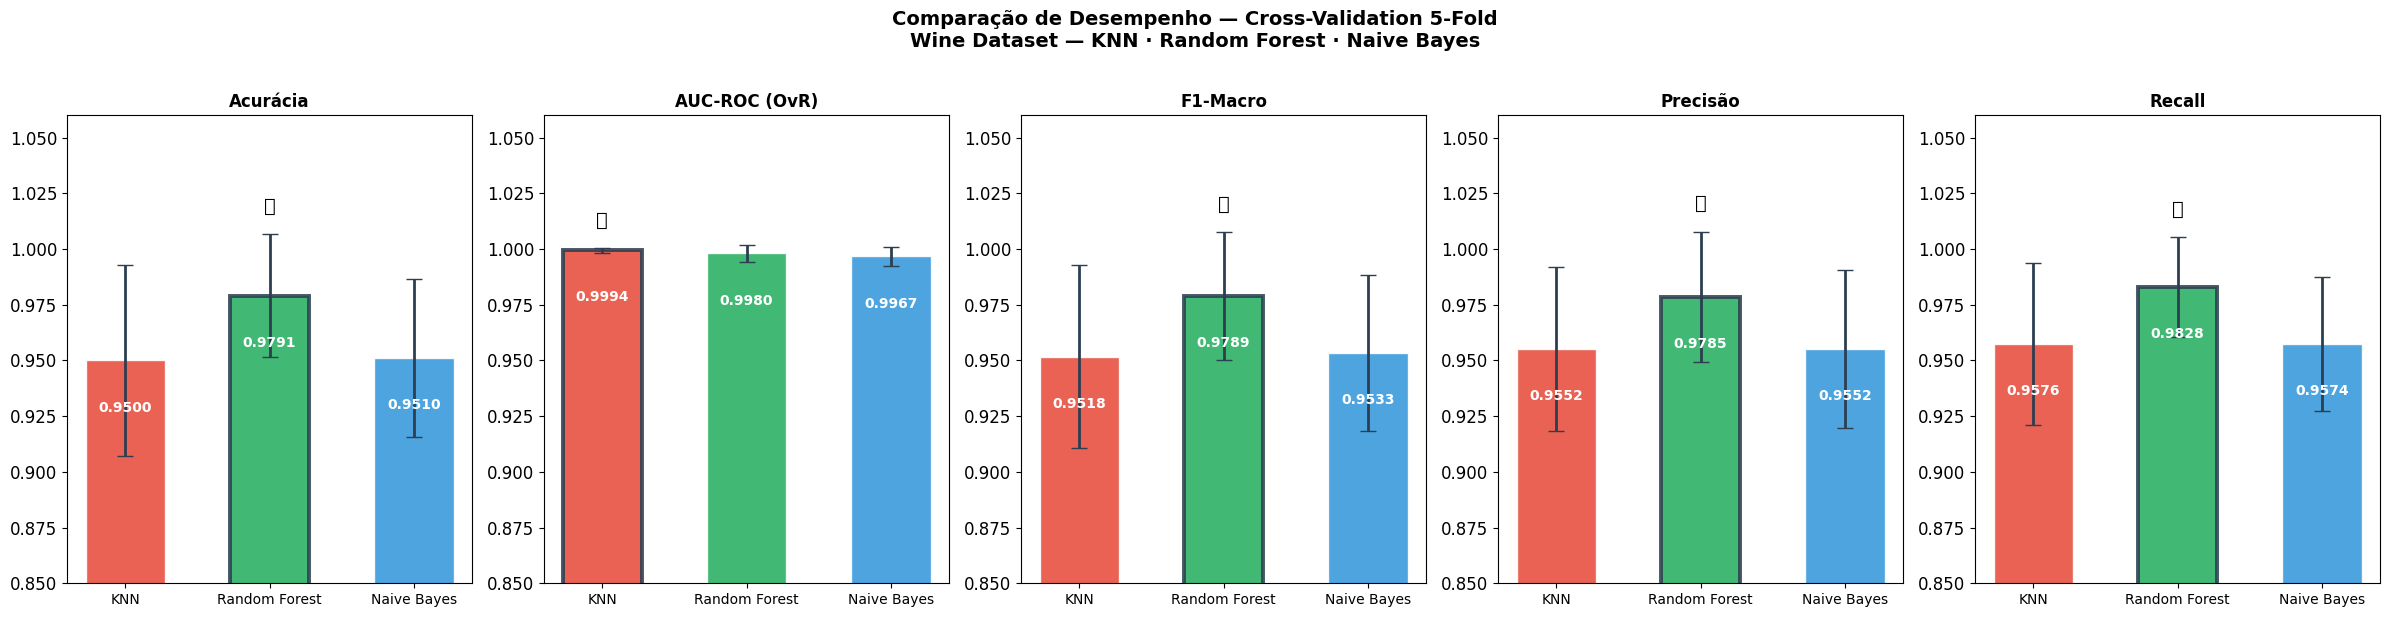

In [86]:
# Gráfico comparativo de métricas — 5 painéis
metricas_plot = ['accuracy','roc_auc_ovr','f1_macro','precision_macro','recall_macro']
nomes_plot    = ['Acurácia','AUC-ROC (OvR)','F1-Macro','Precisão','Recall']

fig, axes = plt.subplots(1, 5, figsize=(24, 6))
for ax, met, lbl in zip(axes, metricas_plot, nomes_plot):
    means = [cv_results[n][met]['mean'] for n in NOMES_ALG]
    stds  = [cv_results[n][met]['std']  for n in NOMES_ALG]
    best  = int(np.argmax(means))
    bars = ax.bar(range(3), means, color=CORES_ALG, edgecolor='white', alpha=0.88, width=0.55)
    ax.errorbar(range(3), means, yerr=stds, fmt='none', color='#2c3e50', capsize=6, lw=2)
    bars[best].set_edgecolor('#2c3e50'); bars[best].set_linewidth(2.8)
    ax.text(best, means[best]+stds[best]+0.01,'🏆', ha='center', fontsize=14)
    ax.set_title(lbl, fontweight='bold', fontsize=12)
    ax.set_xticks(range(3)); ax.set_xticklabels(NOMES_ALG, fontsize=10)
    ax.set_ylim(0.85, 1.06)
    for b, m in zip(bars, means):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()-0.018, f'{m:.4f}',
                ha='center', va='top', color='white', fontweight='bold', fontsize=10)

plt.suptitle('Comparação de Desempenho — Cross-Validation 5-Fold\nWine Dataset — KNN · Random Forest · Naive Bayes',
             fontsize=14, fontweight='bold', y=1.02)
save_fig("cv_comparison")
plt.show()

Saving figure radar_chart


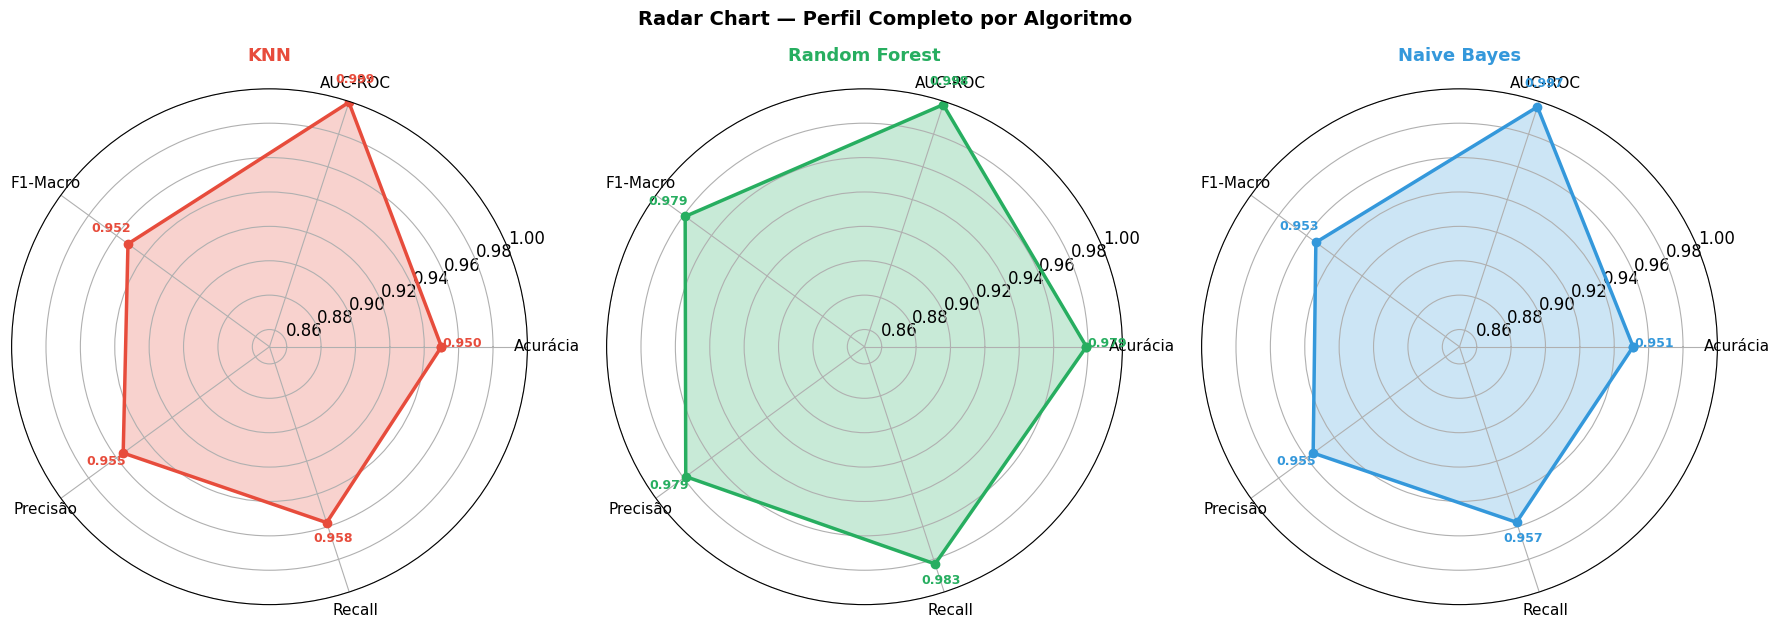

In [87]:
# Radar Chart — perfil completo de cada algoritmo
cats   = ['Acurácia','AUC-ROC','F1-Macro','Precisão','Recall']
met_k  = ['accuracy','roc_auc_ovr','f1_macro','precision_macro','recall_macro']
N      = len(cats)
angles = [n/float(N)*2*np.pi for n in range(N)] + [0]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))
for ax, nome, cor in zip(axes, NOMES_ALG, CORES_ALG):
    vals = [cv_results[nome][m]['mean'] for m in met_k] + [cv_results[nome][met_k[0]]['mean']]
    ax.plot(angles, vals, 'o-', lw=2.5, color=cor)
    ax.fill(angles, vals, alpha=0.25, color=cor)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats, fontsize=11)
    ax.set_ylim(0.85, 1.0)
    ax.set_title(nome, fontsize=13, fontweight='bold', pad=20, color=cor)
    for angle, val in zip(angles[:-1], vals[:-1]):
        ax.text(angle, val+0.012, f'{val:.3f}', ha='center', fontsize=9, color=cor, fontweight='bold')

plt.suptitle('Radar Chart — Perfil Completo por Algoritmo', fontsize=14, fontweight='bold', y=1.02)
save_fig("radar_chart")
plt.show()

# Fine-Tune Your Model

## Grid Search

In [88]:
# Mesmo do Cap. 2 — GridSearchCV no melhor modelo (Random Forest)
from sklearn.model_selection import GridSearchCV

param_grid = [
    # Grade 1: 3×2 = 6 combinações
    {'n_estimators': [50, 100, 200], 'max_features': ['sqrt', 'log2']},
    # Grade 2: 3×2 = 6 combinações com profundidade limitada
    {'n_estimators': [50, 100], 'max_features': ['sqrt', 'log2'], 'max_depth': [5, 10]},
]

forest_reg2  = RandomForestClassifier(random_state=42)
grid_search  = GridSearchCV(
    forest_reg2, param_grid,
    cv=5, scoring='roc_auc_ovr',
    verbose=1, n_jobs=-1
)
grid_search.fit(wine_prepared, wine_labels)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid=[{'max_features': ['sqrt', 'log2'],
                          'n_estimators': [50, 100, 200]},
                         {'max_depth': [5, 10],
                          'max_features': ['sqrt', 'log2'],
                          'n_estimators': [50, 100]}],
             scoring='roc_auc_ovr', verbose=1)

In [89]:
# Melhores hiperparâmetros — igual ao Cap. 2
grid_search.best_params_

{'max_features': 'sqrt', 'n_estimators': 50}

In [90]:
grid_search.best_estimator_

RandomForestClassifier(n_estimators=50, random_state=42)

In [91]:
# Score de cada combinação testada
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres['mean_test_score'], cvres['params']):
    print(round(mean_score, 4), params)

0.9996 {'max_features': 'sqrt', 'n_estimators': 50}
0.9993 {'max_features': 'sqrt', 'n_estimators': 100}
0.9993 {'max_features': 'sqrt', 'n_estimators': 200}
0.9996 {'max_features': 'log2', 'n_estimators': 50}
0.9993 {'max_features': 'log2', 'n_estimators': 100}
0.9993 {'max_features': 'log2', 'n_estimators': 200}
0.9996 {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 50}
0.9993 {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}
0.9996 {'max_depth': 5, 'max_features': 'log2', 'n_estimators': 50}
0.9993 {'max_depth': 5, 'max_features': 'log2', 'n_estimators': 100}
0.9996 {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}
0.9993 {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
0.9996 {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 50}
0.9993 {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 100}


In [92]:
pd.DataFrame(grid_search.cv_results_)[[
    'params','mean_test_score','std_test_score','rank_test_score'
]].sort_values('rank_test_score').head(10)

,params,mean_test_score,std_test_score,rank_test_score
0,"{'max_features': 'sqrt', 'n_estimators': 50}",0.999643,0.000713,1
3,"{'max_features': 'log2', 'n_estimators': 50}",0.999643,0.000713,1
6,"{'max_depth': 5, 'max_features': 'sqrt', 'n_es...",0.999643,0.000713,1
8,"{'max_depth': 5, 'max_features': 'log2', 'n_es...",0.999643,0.000713,1
10,"{'max_depth': 10, 'max_features': 'sqrt', 'n_e...",0.999643,0.000713,1
12,"{'max_depth': 10, 'max_features': 'log2', 'n_e...",0.999643,0.000713,1
2,"{'max_features': 'sqrt', 'n_estimators': 200}",0.999317,0.000838,7
1,"{'max_features': 'sqrt', 'n_estimators': 100}",0.999317,0.000838,7
7,"{'max_depth': 5, 'max_features': 'sqrt', 'n_es...",0.999317,0.000838,7
5,"{'max_features': 'log2', 'n_estimators': 200}",0.999317,0.000838,7


## Randomized Search

In [93]:
# Mesmo do Cap. 2 — RandomizedSearchCV no KNN
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    'n_neighbors': randint(low=3, high=15),
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan', 'minkowski'],
}

knn_reg2   = KNeighborsClassifier()
rnd_search = RandomizedSearchCV(
    knn_reg2, param_distribs,
    n_iter=20, cv=5,
    scoring='roc_auc_ovr',
    random_state=42, verbose=1, n_jobs=-1
)
rnd_search.fit(wine_prepared, wine_labels)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(), n_iter=20, n_jobs=-1,
                   param_distributions={'metric': ['euclidean', 'manhattan',
                                                   'minkowski'],
                                        'n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a8c52637470>,
                                        'weights': ['uniform', 'distance']},
                   random_state=42, scoring='roc_auc_ovr', verbose=1)

In [94]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres['mean_test_score'], cvres['params']):
    print(round(mean_score, 4), params)

0.9993 {'metric': 'minkowski', 'n_neighbors': 6, 'weights': 'uniform'}
1.0 {'metric': 'minkowski', 'n_neighbors': 13, 'weights': 'distance'}
0.9991 {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
0.9997 {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
1.0 {'metric': 'minkowski', 'n_neighbors': 13, 'weights': 'distance'}
0.9996 {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'distance'}
1.0 {'metric': 'minkowski', 'n_neighbors': 8, 'weights': 'uniform'}
0.9993 {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}
1.0 {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'distance'}
0.9862 {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
0.9993 {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'uniform'}
0.9861 {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
0.9996 {'metric': 'minkowski', 'n_neighbors': 12, 'weights': 'distance'}
1.0 {'metric': 'minkowski', 'n_neighbors': 5, 'weights': 'distance'}
0.9996 {'

## Analyze the Best Models and Their Errors

In [95]:
# Importância das features — igual ao Cap. 2
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([0.05181576, 0.02141025, 0.00491214, 0.01371001, 0.01127697,
       0.03911483, 0.12014876, 0.00170518, 0.01483826, 0.19479413,
       0.08590113, 0.07952792, 0.16496455, 0.00826185, 0.05719492,
       0.03900581, 0.09141753])

In [96]:
# Nomes das features após o pipeline
feat_names_orig = list(wine_feat.columns)
feat_names_new  = feat_names_orig + ['alcohol_acid_ratio','polyphenol_index','flavanoid_ratio','color_score']

fi_df = pd.DataFrame({'Feature': feat_names_new, 'Importance': feature_importances})\
          .sort_values('Importance', ascending=False)

sorted(zip(feature_importances, feat_names_new), reverse=True)

[(np.float64(0.19479413442061017), 'color_intensity'),
 (np.float64(0.16496454698860816), 'proline'),
 (np.float64(0.1201487631892854), 'flavanoids'),
 (np.float64(0.09141752986275496), 'color_score'),
 (np.float64(0.08590113236153694), 'hue'),
 (np.float64(0.07952791610767108), 'od280/od315_of_diluted_wines'),
 (np.float64(0.05719492450921932), 'polyphenol_index'),
 (np.float64(0.051815756507276114), 'alcohol'),
 (np.float64(0.039114832528487346), 'total_phenols'),
 (np.float64(0.03900580760985077), 'flavanoid_ratio'),
 (np.float64(0.021410247236620255), 'malic_acid'),
 (np.float64(0.014838261629334376), 'proanthocyanins'),
 (np.float64(0.013710009125077189), 'alcalinity_of_ash'),
 (np.float64(0.011276965194362462), 'magnesium'),
 (np.float64(0.008261853828038832), 'alcohol_acid_ratio'),
 (np.float64(0.004912142093008991), 'ash'),
 (np.float64(0.0017051768082576178), 'nonflavanoid_phenols')]

Saving figure feature_importances


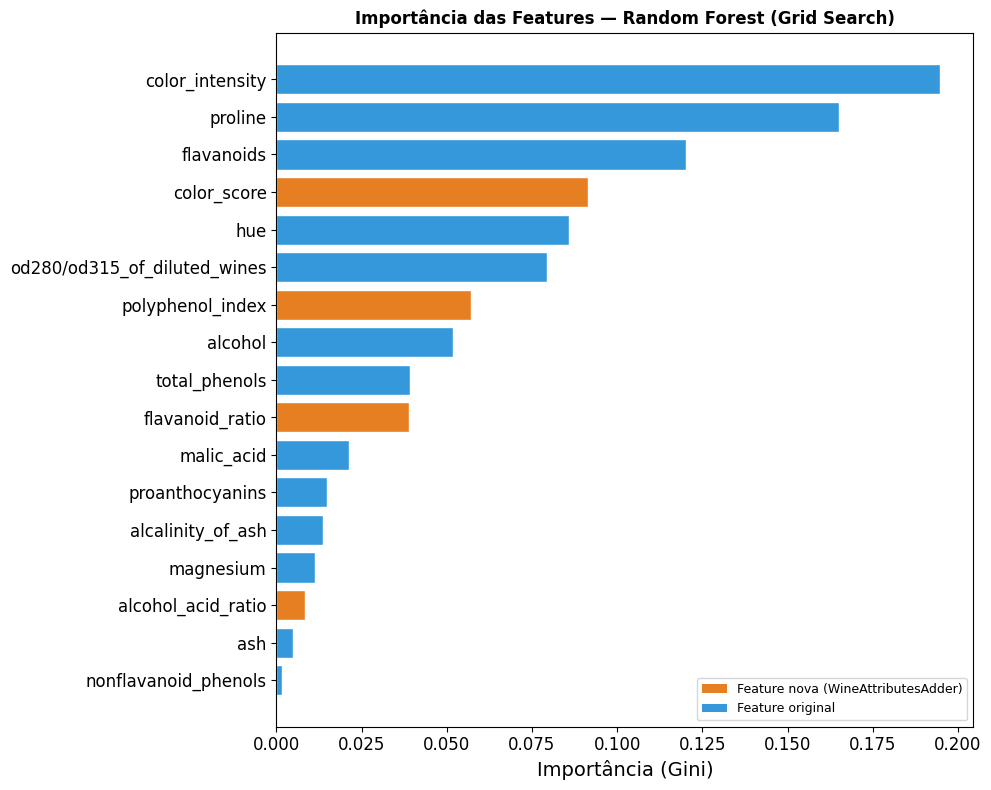

In [97]:
# Gráfico de importância das features
novas_set = {'alcohol_acid_ratio','polyphenol_index','flavanoid_ratio','color_score'}
bar_colors = ['#e67e22' if f in novas_set else '#3498db' for f in fi_df['Feature']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
        color=bar_colors[::-1], edgecolor='white')
ax.set_title('Importância das Features — Random Forest (Grid Search)', fontweight='bold')
ax.set_xlabel('Importância (Gini)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e67e22', label='Feature nova (WineAttributesAdder)'),
                   Patch(facecolor='#3498db', label='Feature original')],
          loc='lower right', fontsize=9)
save_fig("feature_importances")
plt.show()

## Evaluate Your System on the Test Set

In [98]:
# ⚠️ Executar somente uma vez — mesmo aviso do Cap. 2
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

final_model = grid_search.best_estimator_

X_test       = strat_test_set.drop('target', axis=1)
y_test       = strat_test_set['target'].copy()
X_test_prep  = full_pipeline.transform(X_test)

final_preds  = final_model.predict(X_test_prep)
final_probas = final_model.predict_proba(X_test_prep)

final_auc = roc_auc_score(y_test, final_probas, multi_class='ovr')
final_f1  = f1_score(y_test, final_preds, average='macro')
final_acc = accuracy_score(y_test, final_preds)

print('📊 RESULTADO FINAL NO CONJUNTO DE TESTE')
print('='*50)
print(f'Modelo  : Random Forest (Grid Search)')
print(f'Params  : {grid_search.best_params_}')
print()
print(f'AUC-ROC (OvR) : {final_auc:.4f}')
print(f'F1-Macro      : {final_f1:.4f}')
print(f'Acurácia      : {final_acc:.4f}')
print()
print(classification_report(y_test, final_preds,
                             target_names=['Cultivar A','Cultivar B','Cultivar C']))

📊 RESULTADO FINAL NO CONJUNTO DE TESTE
Modelo  : Random Forest (Grid Search)
Params  : {'max_features': 'sqrt', 'n_estimators': 50}

AUC-ROC (OvR) : 1.0000
F1-Macro      : 1.0000
Acurácia      : 1.0000

              precision    recall  f1-score   support

  Cultivar A       1.00      1.00      1.00        12
  Cultivar B       1.00      1.00      1.00        14
  Cultivar C       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



Saving figure confusion_matrices


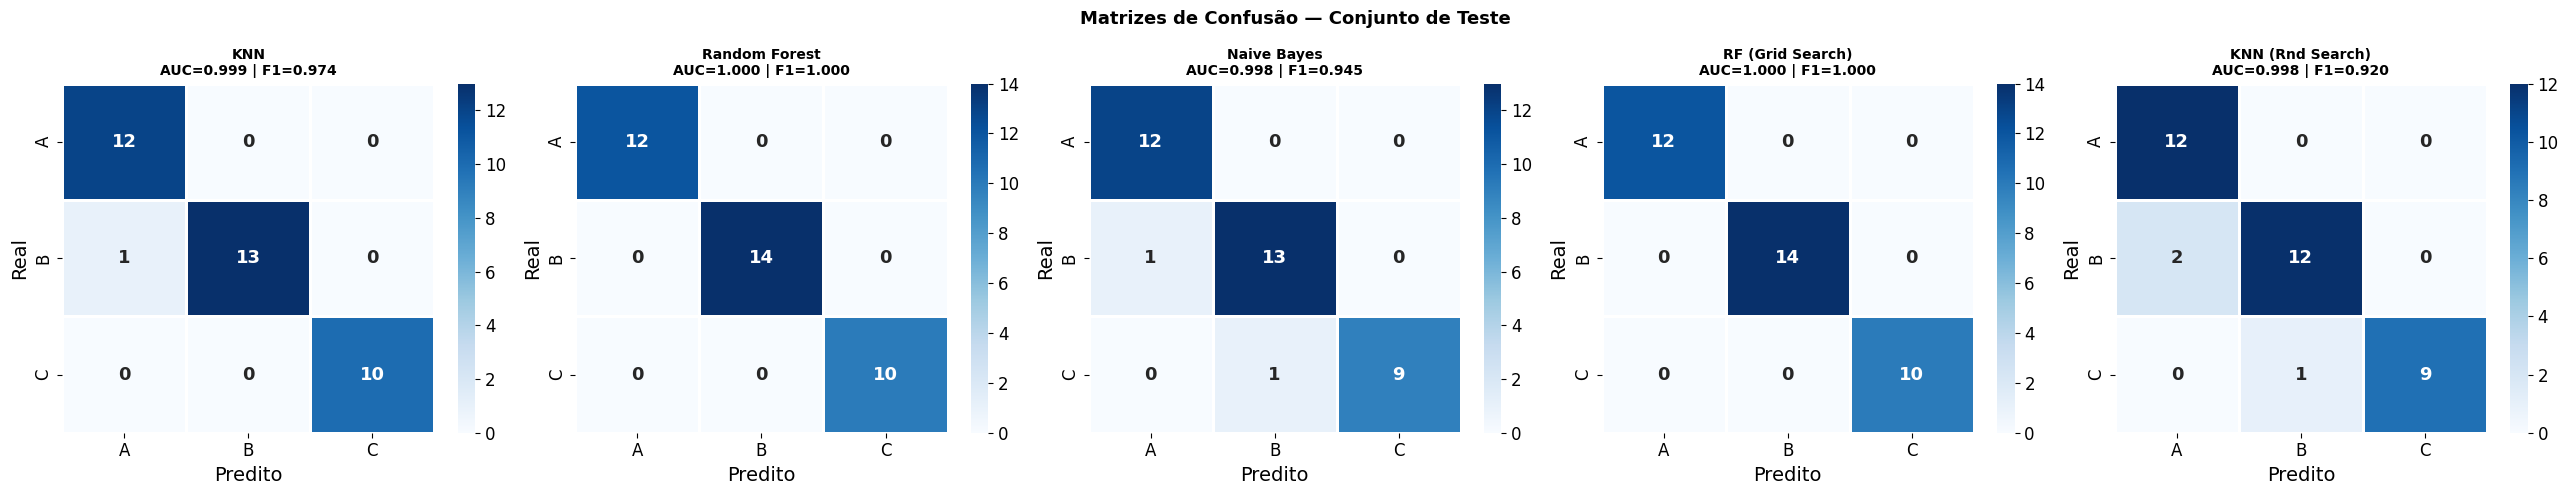

In [99]:
# Matrizes de confusão — todos os 3 modelos + otimizados
modelos_finais = {
    'KNN':                knn_reg,
    'Random Forest':      forest_reg,
    'Naive Bayes':        nb_reg,
    'RF (Grid Search)':   grid_search.best_estimator_,
    'KNN (Rnd Search)':   rnd_search.best_estimator_,
}

fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for ax, (nome, modelo) in zip(axes, modelos_finais.items()):
    yp  = modelo.predict(X_test_prep)
    ypr = modelo.predict_proba(X_test_prep)
    cm  = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['A','B','C'], yticklabels=['A','B','C'],
                linewidths=0.8, linecolor='white', annot_kws={'size':13,'weight':'bold'})
    auc_v = roc_auc_score(y_test, ypr, multi_class='ovr')
    f1_v  = f1_score(y_test, yp, average='macro')
    ax.set_title(f'{nome}\nAUC={auc_v:.3f} | F1={f1_v:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=13, fontweight='bold')
save_fig("confusion_matrices")
plt.tight_layout()
plt.show()

Saving figure roc_curves


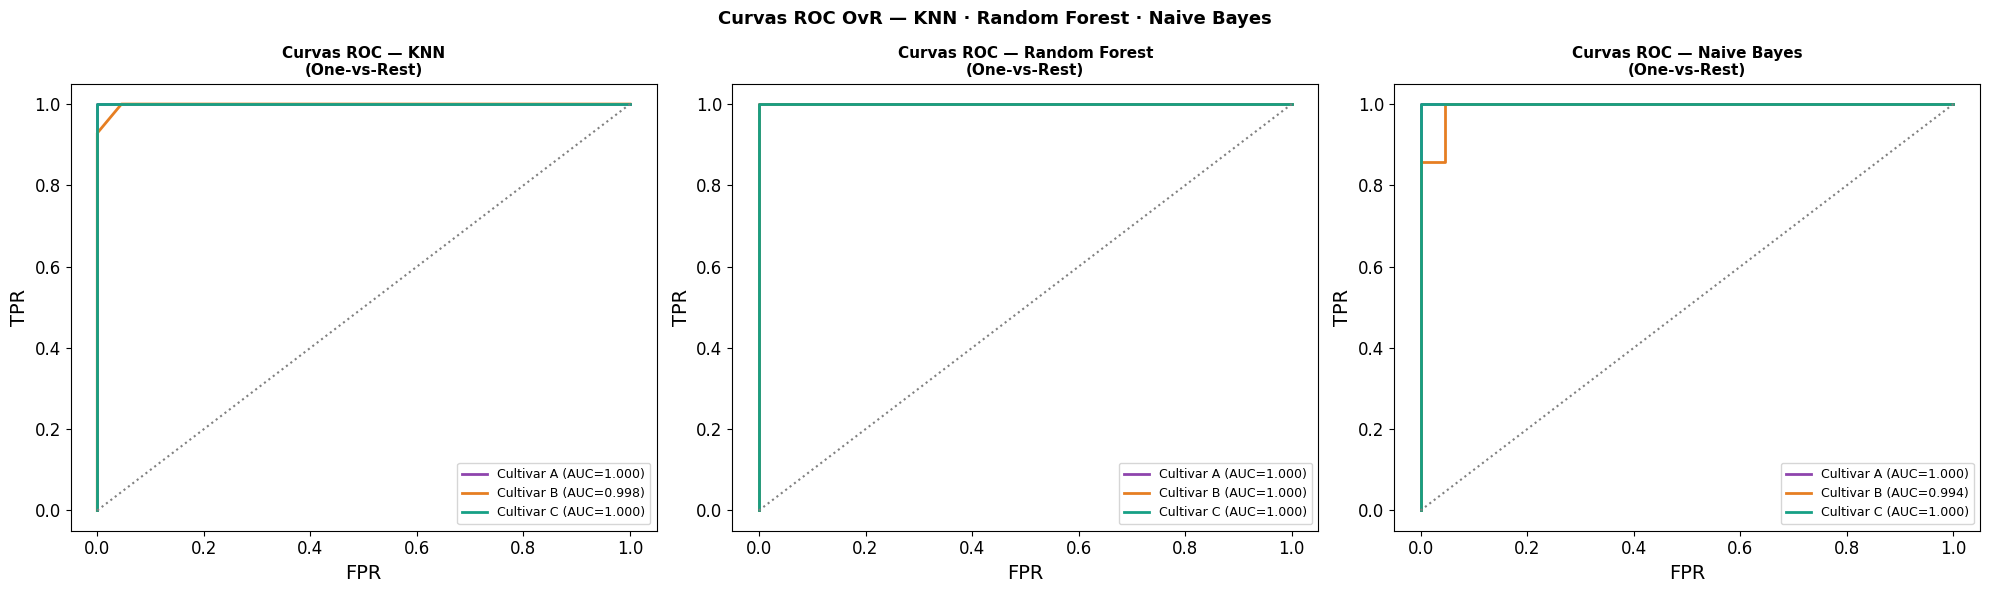

In [100]:
# Curvas ROC One-vs-Rest — igual ao Cap. 2 usa curva de erro
CORES_WINE = ['#8e44ad','#e67e22','#16a085']
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (nome, modelo), cor_alg in zip(axes,
    list(modelos_finais.items())[:3], ['#e74c3c','#27ae60','#3498db']):
    ypr = modelo.predict_proba(X_test_prep)
    for cls_i, (cor_c, lbl_c) in enumerate(zip(CORES_WINE,['Cultivar A','Cultivar B','Cultivar C'])):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_i], ypr[:, cls_i])
        ax.plot(fpr, tpr, lw=2, color=cor_c, label=f'{lbl_c} (AUC={auc(fpr,tpr):.3f})')
    ax.plot([0,1],[0,1],':',color='gray',lw=1.5)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'Curvas ROC — {nome}\n(One-vs-Rest)', fontweight='bold', fontsize=11)
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle('Curvas ROC OvR — KNN · Random Forest · Naive Bayes',
             fontsize=13, fontweight='bold')
save_fig("roc_curves")
plt.tight_layout()
plt.show()

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize

In [101]:
# Ranking final — Tabela com todas as métricas no teste
rank_rows = []
for nome, modelo in modelos_finais.items():
    yp  = modelo.predict(X_test_prep)
    ypr = modelo.predict_proba(X_test_prep)
    rank_rows.append({
        'Modelo':      nome,
        'AUC-ROC(OvR)': roc_auc_score(y_test, ypr, multi_class='ovr'),
        'F1-Macro':    f1_score(y_test, yp, average='macro'),
        'Acurácia':    accuracy_score(y_test, yp),
        'Precisão':    precision_score(y_test, yp, average='macro'),
        'Recall':      recall_score(y_test, yp, average='macro'),
        'Erros':       int((yp != y_test.values).sum()),
    })

df_rank = pd.DataFrame(rank_rows).set_index('Modelo')
df_rank['Score'] = (0.40*df_rank['AUC-ROC(OvR)'] +
                    0.35*df_rank['F1-Macro'] +
                    0.25*df_rank['Acurácia'])
df_rank = df_rank.sort_values('Score', ascending=False)

print('🏆 RANKING FINAL:')
print(df_rank.round(4).to_string())

🏆 RANKING FINAL:
                  AUC-ROC(OvR)  F1-Macro  Acurácia  Precisão  Recall  Erros   Score
Modelo                                                                             
Random Forest           1.0000    1.0000    1.0000    1.0000  1.0000      0  1.0000
RF (Grid Search)        1.0000    1.0000    1.0000    1.0000  1.0000      0  1.0000
KNN                     0.9995    0.9743    0.9722    0.9744  0.9762      1  0.9839
Naive Bayes             0.9978    0.9453    0.9444    0.9505  0.9429      2  0.9661
KNN (Rnd Search)        0.9978    0.9198    0.9167    0.9267  0.9190      3  0.9502


In [102]:
# Heatmap do ranking
heat_cols = ['AUC-ROC(OvR)','F1-Macro','Acurácia','Precisão','Recall']
df_rank[heat_cols].style\
    .background_gradient(cmap='RdYlGn', axis=0)\
    .format('{:.4f}')\
    .set_caption('🏆 Comparação Final — Conjunto de Teste')

,AUC-ROC(OvR),F1-Macro,Acurácia,Precisão,Recall
Modelo,,,,,
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
RF (Grid Search),1.0000,1.0000,1.0000,1.0000,1.0000
KNN,0.9995,0.9743,0.9722,0.9744,0.9762
Naive Bayes,0.9978,0.9453,0.9444,0.9505,0.9429
KNN (Rnd Search),0.9978,0.9198,0.9167,0.9267,0.9190


# Extra material

## A full pipeline with both preparation and prediction

In [103]:
# Pipeline completo — mesmo do Cap. 2
full_pipeline_with_predictor = Pipeline([
    ('preparation', full_pipeline),
    ('random_forest', grid_search.best_estimator_)
])

X_all = wine.drop('target', axis=1)
y_all = wine['target']
full_pipeline_with_predictor.fit(X_all, y_all)

print('Predições em 4 exemplos:')
some = X_all.iloc[:4]
print('  Predições:', full_pipeline_with_predictor.predict(some))
print('  Reais    :', y_all.iloc[:4].values)

Predições em 4 exemplos:
  Predições: [0 0 0 0]
  Reais    : [0 0 0 0]


## Model persistence using joblib

In [104]:
# Mesmo do Cap. 2 — salvar e carregar o modelo
import joblib

joblib.dump(full_pipeline_with_predictor, 'modelo_vinho.pkl')
print('✅ Modelo salvo: modelo_vinho.pkl')

modelo_carregado = joblib.load('modelo_vinho.pkl')
preds = modelo_carregado.predict(some)
probas = modelo_carregado.predict_proba(some)

print(f'✅ Modelo carregado e testado!')
for i, (pred, prob) in enumerate(zip(preds, probas), 1):
    cultivar = ['Cultivar A','Cultivar B','Cultivar C'][pred]
    print(f'  Vinho {i}: {cultivar}  (P0={prob[0]:.2f} P1={prob[1]:.2f} P2={prob[2]:.2f})')

✅ Modelo salvo: modelo_vinho.pkl
✅ Modelo carregado e testado!
  Vinho 1: Cultivar A  (P0=1.00 P1=0.00 P2=0.00)
  Vinho 2: Cultivar A  (P0=1.00 P1=0.00 P2=0.00)
  Vinho 3: Cultivar A  (P0=1.00 P1=0.00 P2=0.00)
  Vinho 4: Cultivar A  (P0=1.00 P1=0.00 P2=0.00)
